In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anjalibhegam/multimodal-sports-injury-dataset/README.md
/kaggle/input/datasets/anjalibhegam/multimodal-sports-injury-dataset/multimodal_sports_injury_dataset.csv


In [2]:
import glob, time, os, json
import numpy as np
import pandas as pd

csv_path = glob.glob("/kaggle/input/**/*.csv", recursive=True)[0]
raw = pd.read_csv(csv_path)
print("Loaded:", csv_path)
print("Rows, Columns:", raw.shape)

Loaded: /kaggle/input/datasets/anjalibhegam/multimodal-sports-injury-dataset/multimodal_sports_injury_dataset.csv
Rows, Columns: (15420, 29)


In [3]:
keep_cols = ["athlete_id", "session_id",
             "training_duration", "training_intensity", "training_load",
             "heart_rate", "sleep_quality", "recovery_score", "stress_level",
             "fatigue_index"]
df = raw[keep_cols].copy()
print(df.shape)
df.head()

(15420, 10)


,athlete_id,session_id,training_duration,training_intensity,training_load,heart_rate,sleep_quality,recovery_score,stress_level,fatigue_index
0,1,1,79.106564,5.678475,548.417962,NaN,5.466370,77.899691,0.375825,45.028687
1,1,2,116.954654,NaN,538.043815,40.000000,6.899090,74.845323,0.279165,42.254717
2,1,3,96.354742,6.643242,647.784339,76.174609,9.574152,83.538316,0.334061,61.870056
3,1,4,97.619130,6.194427,336.553431,100.543724,7.614297,79.966618,0.218766,50.268845
4,1,5,83.155527,5.835804,496.076352,78.001235,5.631979,56.945979,0.484086,29.233575


In [4]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())
print("\nFully duplicated rows:", df.duplicated().sum())
print("Repeated athlete+session pairs:", df.duplicated(subset=["athlete_id", "session_id"]).sum())
print("\n=== VALUE RANGES (outliers are NOT deleted) ===")
print(df.describe().T[["min", "mean", "max"]].round(2))

=== MISSING VALUES ===
athlete_id              0
session_id              0
training_duration       0
training_intensity    632
training_load           0
heart_rate            354
sleep_quality         493
recovery_score          0
stress_level            0
fatigue_index           0
dtype: int64

Fully duplicated rows: 0
Repeated athlete+session pairs: 0

=== VALUE RANGES (outliers are NOT deleted) ===
                       min    mean      max
athlete_id            1.00   78.55   156.00
session_id            1.00   49.93   101.00
training_duration    30.00   87.79   180.00
training_intensity    2.00    6.40    10.00
training_load       150.00  670.53  2632.64
heart_rate           40.00   72.69   159.27
sleep_quality         1.16    5.82    10.00
recovery_score        8.90   55.20    98.00
stress_level          0.10    0.42     0.95
fatigue_index        15.00   59.70   270.19


In [5]:
df = df.sort_values(["athlete_id", "session_id"]).reset_index(drop=True)
df["session_number"] = df.groupby("athlete_id").cumcount() + 1
print(df.groupby("athlete_id")["session_number"].max().describe().round(1))

count    156.0
mean      98.8
std        0.9
min       98.0
25%       98.0
50%       99.0
75%       99.0
max      101.0
Name: session_number, dtype: float64


In [6]:
g = df.groupby("athlete_id")

for w in [7, 14]:
    df[f"load_sum_{w}"] = g["training_load"].transform(
        lambda s: s.shift(1).rolling(w, min_periods=w).sum())
    df[f"load_mean_{w}"] = g["training_load"].transform(
        lambda s: s.shift(1).rolling(w, min_periods=w).mean())
    df[f"load_minus_mean_{w}"] = df["training_load"] - df[f"load_mean_{w}"]   # today vs history
    df[f"load_ratio_{w}"] = df["training_load"] / df[f"load_mean_{w}"]        # today vs history

for col in ["training_intensity", "heart_rate", "sleep_quality",
            "recovery_score", "stress_level"]:
    for w in [7, 14]:
        df[f"{col}_mean_{w}"] = g[col].transform(
            lambda s: s.shift(1).rolling(w, min_periods=3).mean())

df = df.replace([np.inf, -np.inf], np.nan)
print("Total columns now:", df.shape[1])

Total columns now: 29


In [7]:
a = df[df["athlete_id"] == df["athlete_id"].iloc[0]].reset_index(drop=True)
row15 = a[a["session_number"] == 15].iloc[0]

manual_sum7  = a[(a.session_number >= 8) & (a.session_number <= 14)]["training_load"].sum()
manual_sum14 = a[(a.session_number >= 1) & (a.session_number <= 14)]["training_load"].sum()

assert np.isclose(row15["load_sum_7"], manual_sum7)
assert np.isclose(row15["load_sum_14"], manual_sum14)
print("OK: windows use only earlier sessions.")
print("Correlation of 7- and 14-session load totals:",
      round(df["load_sum_7"].corr(df["load_sum_14"]), 3))      # earlier run: 0.729

OK: windows use only earlier sessions.
Correlation of 7- and 14-session load totals: 0.729


In [8]:
model_df = df[df["session_number"] >= 15].copy()          # session 15 = first prediction

train_df = model_df[model_df["session_number"] <= 75].copy()
q1, q2 = train_df["fatigue_index"].quantile([1/3, 2/3])   # cut points from TRAINING data only
print("Class cut points:", round(q1, 2), round(q2, 2))     # expect 47.4 and 68.77

def to_class(x):
    return 0 if x <= q1 else (1 if x <= q2 else 2)

class_names = ["Low", "Moderate", "High"]
model_df["fatigue_class"] = model_df["fatigue_index"].apply(to_class)

train_df = model_df[model_df["session_number"] <= 75].copy()   # sessions 15-75
test_df  = model_df[model_df["session_number"] >= 76].copy()   # sessions 76 onward

print("Train rows:", len(train_df), "| Test rows:", len(test_df))   # expect 9516 and 3720
print(train_df["fatigue_class"].value_counts().sort_index())
print(test_df["fatigue_class"].value_counts().sort_index())

Class cut points: 47.4 68.77
Train rows: 9516 | Test rows: 3720
fatigue_class
0    3172
1    3172
2    3172
Name: count, dtype: int64
fatigue_class
0    1304
1    1232
2    1184
Name: count, dtype: int64


In [9]:
today_feats = ["training_duration", "training_intensity", "training_load",
               "heart_rate", "sleep_quality", "recovery_score", "stress_level"]

comparison_feats = ["load_minus_mean_7", "load_minus_mean_14",
                    "load_ratio_7", "load_ratio_14"]

history_pure = (["load_sum_7", "load_sum_14", "load_mean_7", "load_mean_14"] +
                [f"{c}_mean_{w}" for c in ["training_intensity", "heart_rate", "sleep_quality",
                                           "recovery_score", "stress_level"] for w in [7, 14]])

features = today_feats + history_pure + comparison_feats

feature_group = {}
for f in today_feats:      feature_group[f] = "Today"
for f in history_pure:     feature_group[f] = "History (previous sessions)"
for f in comparison_feats: feature_group[f] = "Today vs history"

X_train, y_train = train_df[features], train_df["fatigue_class"]
X_test,  y_test  = test_df[features],  test_df["fatigue_class"]

print("Today:", len(today_feats), "| History:", len(history_pure),
      "| Today vs history:", len(comparison_feats), "| Total:", len(features))   # 7, 14, 4, 25
print("fatigue_index in features?", "fatigue_index" in features)               # must be False

Today: 7 | History: 14 | Today vs history: 4 | Total: 25
fatigue_index in features? False


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, log_loss,
                             confusion_matrix, classification_report)
import xgboost
print("xgboost version:", xgboost.__version__)

def make_xgb(**kw):
    params = dict(objective="multi:softprob", n_estimators=300, learning_rate=0.1,
                  max_depth=6, subsample=0.8, colsample_bytree=0.8,
                  eval_metric="mlogloss", tree_method="hist",
                  random_state=42, n_jobs=-1)
    params.update(kw)
    return Pipeline([
        ("fill_missing", SimpleImputer(strategy="median")),   # medians learned from training data only
        ("model", XGBClassifier(**params)),
    ])

def score(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr_macro": roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
    }

def run_xgb(feats, tr, te, **kw):
    pipe = make_xgb(**kw)
    t0 = time.perf_counter()
    pipe.fit(tr[feats], tr["fatigue_class"])
    train_t = time.perf_counter() - t0
    t0 = time.perf_counter()
    pred = pipe.predict(te[feats])
    proba = pipe.predict_proba(te[feats])
    pred_t = time.perf_counter() - t0
    return pipe, pred, proba, score(te["fatigue_class"], pred, proba), train_t, pred_t

# Main model: fixed 300 trees, default-style settings, NOT tuned
main_pipe, y_pred, y_proba, main_metrics, train_wall_time, predict_wall_time = run_xgb(features, train_df, test_df)

print(f"Training wall time:   {train_wall_time:.4f} seconds")
print(f"Prediction wall time: {predict_wall_time:.4f} seconds")

xgboost version: 3.4.1
Training wall time:   3.2743 seconds
Prediction wall time: 0.0762 seconds


In [11]:
for k, v in main_metrics.items():
    print(f"{k:20s}: {v:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix (rows = true, columns = predicted):")
print(pd.DataFrame(cm, index=[f"true_{n}" for n in class_names],
                   columns=[f"pred_{n}" for n in class_names]))
print("\n", classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

accuracy            : 0.6516
balanced_accuracy   : 0.6516
precision_macro     : 0.6510
recall_macro        : 0.6516
f1_macro            : 0.6513
f1_weighted         : 0.6515
roc_auc_ovr_macro   : 0.8364

Confusion matrix (rows = true, columns = predicted):
               pred_Low  pred_Moderate  pred_High
true_Low            922            323         59
true_Moderate       325            630        277
true_High            36            276        872

               precision    recall  f1-score   support

         Low       0.72      0.71      0.71      1304
    Moderate       0.51      0.51      0.51      1232
        High       0.72      0.74      0.73      1184

    accuracy                           0.65      3720
   macro avg       0.65      0.65      0.65      3720
weighted avg       0.65      0.65      0.65      3720



In [12]:
results = pd.DataFrame([{
    "model": "XGBoost",
    "train_rows": len(X_train), "test_rows": len(X_test), "n_features": len(features),
    "train_wall_time_sec": round(train_wall_time, 4),
    "predict_wall_time_sec": round(predict_wall_time, 4),
    "total_wall_time_sec": round(train_wall_time + predict_wall_time, 4),
    **{k: round(v, 4) for k, v in main_metrics.items()},
}])
results.to_csv("/kaggle/working/xgboost_metrics.csv", index=False)

per_class = pd.DataFrame(classification_report(
    y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)).T
per_class.to_csv("/kaggle/working/xgboost_per_class.csv")

rf_imp = pd.DataFrame({
    "importance": main_pipe.named_steps["model"].feature_importances_,
    "group": [feature_group[f] for f in features]}, index=features
).sort_values("importance", ascending=False)
rf_imp.to_csv("/kaggle/working/xgboost_feature_importance.csv")

test_out = test_df[["athlete_id", "session_id", "session_number", "fatigue_index", "fatigue_class"] + features].copy()
test_out["true_class"] = test_out["fatigue_class"].map(dict(enumerate(class_names)))
test_out["predicted_class"] = pd.Series(y_pred, index=test_out.index).map(dict(enumerate(class_names)))
test_out["correct"] = test_out["true_class"] == test_out["predicted_class"]
for i, name in enumerate(class_names):
    test_out[f"prob_{name}"] = y_proba[:, i].round(4)
test_out.to_csv("/kaggle/working/xgboost_test_predictions.csv", index=False)

print(results.T)
print("\nTop 10 impurity importances:")
print(rf_imp.head(10).round(4))

                             0
model                  XGBoost
train_rows                9516
test_rows                 3720
n_features                  25
train_wall_time_sec     3.2743
predict_wall_time_sec   0.0762
total_wall_time_sec     3.3505
accuracy                0.6516
balanced_accuracy       0.6516
precision_macro          0.651
recall_macro            0.6516
f1_macro                0.6513
f1_weighted             0.6515
roc_auc_ovr_macro       0.8364

Top 10 impurity importances:
                    importance                        group
training_load           0.2631                        Today
load_minus_mean_14      0.0712             Today vs history
load_ratio_14           0.0578             Today vs history
recovery_score          0.0383                        Today
training_duration       0.0316                        Today
load_sum_14             0.0305  History (previous sessions)
load_ratio_7            0.0303             Today vs history
stress_level            0

In [13]:
ablation_sets = {
    "A. Today only":                         today_feats,
    "B. History only (past sessions)":       history_pure,
    "C. Today + history":                    today_feats + history_pure,
    "D. Today + history + comparison (all)": features,
}

rows = []
for name, feats in ablation_sets.items():
    _, p, pr, m, t_tr, t_pr = run_xgb(feats, train_df, test_df)
    rows.append({"feature_set": name, "n_features": len(feats),
                 "train_wall_time_sec": round(t_tr, 4),
                 "predict_wall_time_sec": round(t_pr, 4),
                 **{k: round(v, 4) for k, v in m.items()}})

ablation = pd.DataFrame(rows)
ablation.to_csv("/kaggle/working/xgb_ablation.csv", index=False)
print(ablation[["feature_set", "n_features", "accuracy", "f1_macro", "roc_auc_ovr_macro"]].to_string(index=False))

                          feature_set  n_features  accuracy  f1_macro  roc_auc_ovr_macro
                        A. Today only           7    0.6519    0.6531             0.8388
      B. History only (past sessions)          14    0.3613    0.3609             0.5282
                   C. Today + history          21    0.6516    0.6512             0.8372
D. Today + history + comparison (all)          25    0.6516    0.6513             0.8364


In [14]:
RETRAIN_EVERY = 1     # retrain after every session. Use 5 for fewer, faster retrains.

max_sn = int(model_df["session_number"].max())
starts = list(range(76, max_sn + 1, RETRAIN_EVERY))

upd_true, upd_pred, upd_proba = [], [], []
upd_fit_time, n_fits = 0.0, 0

for s in starts:
    tr = model_df[model_df["session_number"] < s]
    te = model_df[(model_df["session_number"] >= s) & (model_df["session_number"] < s + RETRAIN_EVERY)]
    if len(te) == 0:
        continue
    pipe = make_xgb()
    t0 = time.perf_counter()
    pipe.fit(tr[features], tr["fatigue_class"])
    upd_fit_time += time.perf_counter() - t0
    n_fits += 1
    upd_pred.append(pipe.predict(te[features]))
    upd_proba.append(pipe.predict_proba(te[features]))
    upd_true.append(te["fatigue_class"].values)

upd_true  = np.concatenate(upd_true)
upd_pred  = np.concatenate(upd_pred)
upd_proba = np.concatenate(upd_proba)
updating_metrics = score(upd_true, upd_pred, upd_proba)

wf = pd.DataFrame([
    {"version": "Frozen (trained once on sessions 15-75)", "n_fits": 1,
     "total_train_wall_time_sec": round(train_wall_time, 4),
     **{k: round(v, 4) for k, v in main_metrics.items()}},
    {"version": f"Updating (retrained every {RETRAIN_EVERY} session(s))", "n_fits": n_fits,
     "total_train_wall_time_sec": round(upd_fit_time, 4),
     **{k: round(v, 4) for k, v in updating_metrics.items()}},
])
wf.to_csv("/kaggle/working/xgb_walk_forward.csv", index=False)
print("Rows evaluated (updating):", len(upd_true), "| rows evaluated (frozen):", len(y_test))
print(wf[["version", "n_fits", "accuracy", "f1_macro", "roc_auc_ovr_macro", "total_train_wall_time_sec"]].to_string(index=False))

Rows evaluated (updating): 3720 | rows evaluated (frozen): 3720
                                version  n_fits  accuracy  f1_macro  roc_auc_ovr_macro  total_train_wall_time_sec
Frozen (trained once on sessions 15-75)       1    0.6516    0.6513             0.8364                     3.2743
Updating (retrained every 1 session(s))      26    0.6511    0.6517             0.8373                    72.4918


SHAP array shape (rows, features, classes): (500, 25, 3)

=== Top 10 features ===
                                             group  shap_overall
training_load                                Today        0.9011
recovery_score                               Today        0.2075
load_minus_mean_14                Today vs history        0.1710
training_duration                            Today        0.1439
load_ratio_14                     Today vs history        0.1438
stress_level                                 Today        0.1062
load_minus_mean_7                 Today vs history        0.1032
load_ratio_7                      Today vs history        0.0918
training_intensity                           Today        0.0857
recovery_score_mean_7  History (previous sessions)        0.0837

=== Share of model influence by group (%) ===
group
History (previous sessions)    27.660000
Today                          54.619999
Today vs history               17.730000
Name: shap_overall, dtype: 

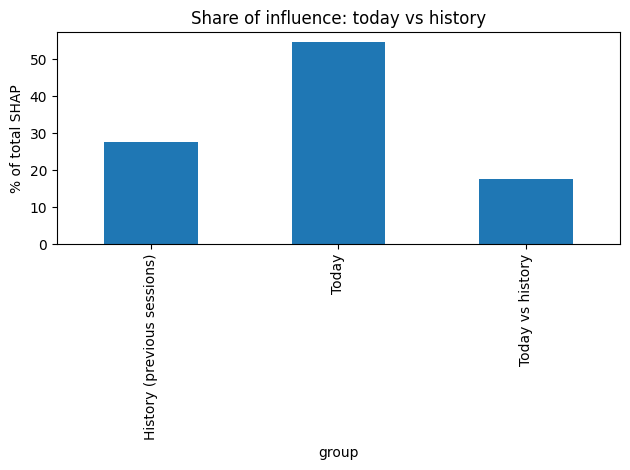

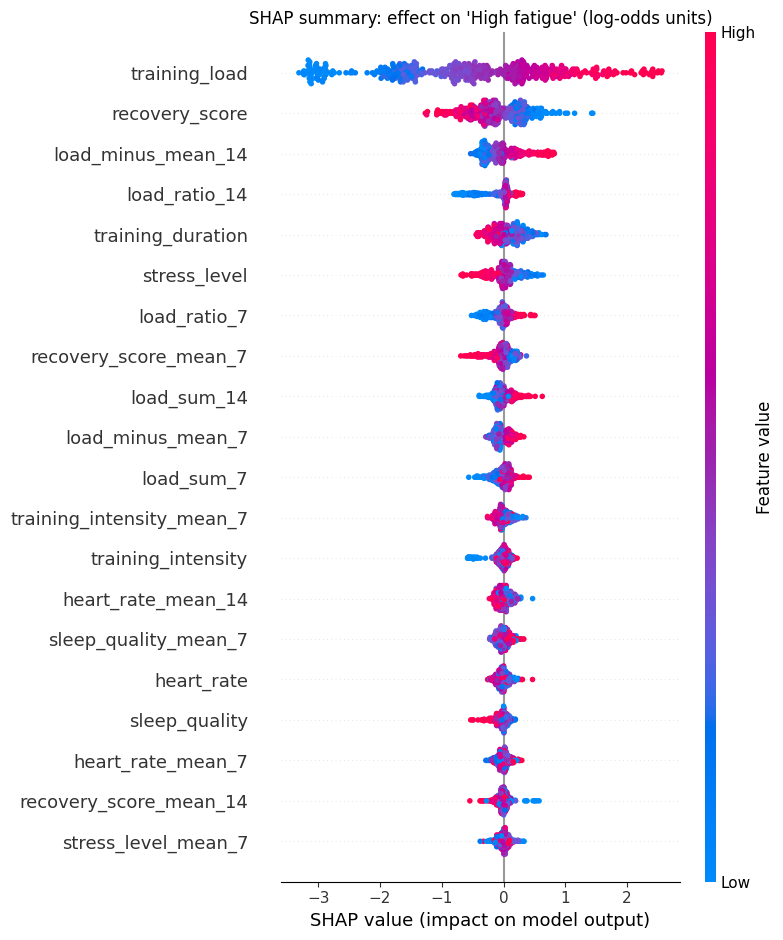


Why this session was predicted 'Low' (top 8 factors):
                            shap_value                        group
recovery_score                   0.378                        Today
recovery_score_mean_7           -0.322  History (previous sessions)
heart_rate_mean_7                0.228  History (previous sessions)
training_intensity_mean_14       0.200  History (previous sessions)
training_load                   -0.198                        Today
load_minus_mean_14               0.138             Today vs history
sleep_quality                    0.133                        Today
training_intensity              -0.094                        Today


In [15]:
!pip install shap -q
import shap
import matplotlib.pyplot as plt

imp_step = main_pipe.named_steps["fill_missing"]
xgb_model = main_pipe.named_steps["model"]
Xte_i = pd.DataFrame(imp_step.transform(X_test), columns=features, index=X_test.index)

rng = np.random.default_rng(0)
shap_idx = rng.choice(len(Xte_i), size=min(500, len(Xte_i)), replace=False)
Xs = Xte_i.iloc[shap_idx]

explainer = shap.TreeExplainer(xgb_model)
sv = explainer.shap_values(Xs.values, check_additivity=False)
if isinstance(sv, list):
    sv = np.stack(sv, axis=-1)                    # -> (rows, features, classes)
print("SHAP array shape (rows, features, classes):", sv.shape)

mean_abs = np.abs(sv).mean(axis=0)
imp = pd.DataFrame(mean_abs, index=features, columns=[f"shap_{n}" for n in class_names])
imp["shap_overall"] = imp.mean(axis=1)
imp["group"] = imp.index.map(feature_group)
imp = imp.sort_values("shap_overall", ascending=False)

group_share = imp.groupby("group")["shap_overall"].sum()
group_pct = (100 * group_share / group_share.sum()).round(2)

print("\n=== Top 10 features ===")
print(imp[["group", "shap_overall"]].head(10).round(4))
print("\n=== Share of model influence by group (%) ===")
print(group_pct)

imp.to_csv("/kaggle/working/xgb_shap_feature_importance.csv")
group_pct.rename("percent_of_total_shap").to_csv("/kaggle/working/xgb_shap_group_share.csv")

group_pct.plot(kind="bar", title="Share of influence: today vs history")
plt.ylabel("% of total SHAP"); plt.tight_layout()
plt.savefig("/kaggle/working/xgb_shap_group_share.png", dpi=150); plt.show()

shap.summary_plot(sv[:, :, 2], Xs.values, feature_names=features, show=False)
plt.title("SHAP summary: effect on 'High fatigue' (log-odds units)")
plt.tight_layout(); plt.savefig("/kaggle/working/xgb_shap_summary_high.png", dpi=150); plt.show()

# Explain ONE prediction
j = 0
pred_cls = int(xgb_model.predict(Xs.iloc[[j]].values)[0])
contrib = pd.Series(sv[j, :, pred_cls], index=features)
contrib = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(8)
print(f"\nWhy this session was predicted '{class_names[pred_cls]}' (top 8 factors):")
print(pd.DataFrame({"shap_value": contrib.round(3), "group": contrib.index.map(feature_group)}))

In [16]:
# SHAP consistency check: for XGBoost, SHAP is in log-odds (raw margin) units
cls, j = 2, 0
margin_j = xgb_model.predict(Xs.iloc[[j]].values, output_margin=True)[0, cls]
base = np.atleast_1d(explainer.expected_value)[cls]
print("Baseline + sum of SHAP:", round(float(base + sv[j, :, cls].sum()), 4))
print("Model raw score:       ", round(float(margin_j), 4))     # should be very close

from sklearn.inspection import permutation_importance
pi = permutation_importance(main_pipe, X_test, y_test, scoring="f1_macro",
                            n_repeats=5, random_state=42, n_jobs=1)
perm = pd.DataFrame({"f1_drop_when_shuffled": pi.importances_mean,
                     "std": pi.importances_std,
                     "group": [feature_group[f] for f in features]}, index=features
                   ).sort_values("f1_drop_when_shuffled", ascending=False)
perm.to_csv("/kaggle/working/xgb_permutation_importance.csv")
print("\nPermutation importance (bigger drop = more important):")
print(perm.head(10).round(4))

Baseline + sum of SHAP: -1.4007
Model raw score:        -1.4007

Permutation importance (bigger drop = more important):
                            f1_drop_when_shuffled     std  \
training_load                              0.1710  0.0068   
recovery_score                             0.0134  0.0056   
training_duration                          0.0092  0.0030   
load_minus_mean_14                         0.0064  0.0028   
load_ratio_14                              0.0057  0.0029   
load_sum_7                                 0.0049  0.0021   
load_ratio_7                               0.0048  0.0030   
sleep_quality_mean_7                       0.0040  0.0016   
training_intensity_mean_14                 0.0033  0.0023   
training_intensity                         0.0026  0.0029   

                                                  group  
training_load                                     Today  
recovery_score                                    Today  
training_duration                 

In [17]:
adjustable = ["sleep_quality", "recovery_score", "stress_level"]
ranges = {c: (train_df[c].min(), train_df[c].max()) for c in adjustable}

def counterfactual(row, pipe, current_class, n_grid=60):
    trials, meta = [], []
    for col in adjustable:
        lo, hi = ranges[col]
        for val in np.linspace(lo, hi, n_grid):
            t = row.copy()
            t[col] = val
            trials.append(t)
            meta.append((col, val))
    T = pd.DataFrame(trials)[features].astype(float)
    preds = pipe.predict(T)

    found = []
    for col in adjustable:
        lo, hi = ranges[col]
        best = None
        for (c, val), p in zip(meta, preds):
            if c == col and p < current_class:
                change = abs(val - row[col])
                if best is None or change < best[1]:
                    best = (val, change, int(p))
        if best:
            found.append({"factor": col, "current": round(float(row[col]), 2),
                          "change_to": round(float(best[0]), 2),
                          "change_size": round(float(best[1]), 2),
                          "relative_change_%": round(100 * best[1] / (hi - lo), 1),
                          "new_class": class_names[best[2]]})
    return pd.DataFrame(found).sort_values("relative_change_%") if found else pd.DataFrame()

high_pos = np.where(y_pred == 2)[0][0]
example_meta = test_df.iloc[high_pos]
print("Example: athlete", int(example_meta["athlete_id"]), "session", int(example_meta["session_number"]),
      "-> predicted class: High")

advice = counterfactual(X_test.iloc[high_pos], main_pipe, current_class=2)
print(advice if len(advice) else "No single-factor change was enough.")
advice.to_csv("/kaggle/working/xgb_counterfactual_example.csv", index=False)

Example: athlete 1 session 76 -> predicted class: High
           factor  current  change_to  change_size  relative_change_%  \
0   sleep_quality     4.03       2.06         1.97               22.3   
1  recovery_score    37.69      84.41        46.72               52.4   
2    stress_level     0.43       0.91         0.48               56.5   

  new_class  
0  Moderate  
1  Moderate  
2  Moderate  


In [18]:
g = df.groupby("athlete_id")
df["fatigue_prev1"]  = g["fatigue_index"].shift(1)            # shift first: only EARLIER sessions
df["fatigue_mean_7"] = g["fatigue_index"].transform(
    lambda s: s.shift(1).rolling(7, min_periods=3).mean())

pf = model_df.copy()
pf[["fatigue_prev1", "fatigue_mean_7"]] = df.loc[pf.index, ["fatigue_prev1", "fatigue_mean_7"]]
pf_train = pf[pf["session_number"] <= 75]
pf_test  = pf[pf["session_number"] >= 76]
prev_fatigue = ["fatigue_prev1", "fatigue_mean_7"]

sets = {
    "A. Today only": today_feats,
    "E. Today + previous fatigue": today_feats + prev_fatigue,
    "F. Today + history + previous fatigue": today_feats + history_pure + prev_fatigue,
}
rows = []
for name, feats in sets.items():
    _, p, pr, m, _, _ = run_xgb(feats, pf_train, pf_test)
    rows.append({"feature_set": name, "n_features": len(feats),
                 **{k: round(v, 4) for k, v in m.items()}})
out = pd.DataFrame(rows)
out.to_csv("/kaggle/working/xgb_ablation_prev_fatigue.csv", index=False)
print(out[["feature_set", "n_features", "accuracy", "f1_macro", "roc_auc_ovr_macro"]].to_string(index=False))

                          feature_set  n_features  accuracy  f1_macro  roc_auc_ovr_macro
                        A. Today only           7    0.6519    0.6531             0.8388
          E. Today + previous fatigue           9    0.6578    0.6584             0.8394
F. Today + history + previous fatigue          23    0.6495    0.6485             0.8358


In [19]:
# Validation split INSIDE the training period (test set stays untouched)
core_df = model_df[model_df["session_number"] <= 60].copy()                       # train
val_df  = model_df[(model_df["session_number"] >= 61) &
                   (model_df["session_number"] <= 75)].copy()                     # validation
print("Core train:", len(core_df), "| Validation:", len(val_df))

imp_c = SimpleImputer(strategy="median").fit(core_df[features])    # fitted on training rows only
Xc, yc = imp_c.transform(core_df[features]), core_df["fatigue_class"]
Xv, yv = imp_c.transform(val_df[features]),  val_df["fatigue_class"]

def make_es(depth, lr):
    return XGBClassifier(
        objective="multi:softprob",
        n_estimators=1000,            # upper limit: training stops earlier
        learning_rate=lr, max_depth=depth,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="mlogloss",
        early_stopping_rounds=30,     # stop if validation loss has not improved for 30 rounds
        tree_method="hist", random_state=42, n_jobs=-1)

rows, es_models = [], {}
for depth in [3, 4, 6]:
    for lr in [0.05, 0.1]:
        m = make_es(depth, lr)
        t0 = time.perf_counter()
        m.fit(Xc, yc, eval_set=[(Xc, yc), (Xv, yv)], verbose=False)   # early stopping uses the LAST set (validation)
        fit_t = time.perf_counter() - t0
        bi = int(m.best_iteration)
        p = m.predict_proba(Xv, iteration_range=(0, bi + 1))
        rows.append({"max_depth": depth, "learning_rate": lr,
                     "best_iteration": bi, "trees_used": bi + 1,
                     "iterations_run": len(m.evals_result()["validation_1"]["mlogloss"]),
                     "val_logloss": round(log_loss(yv, p, labels=[0, 1, 2]), 4),
                     "val_f1_macro": round(f1_score(yv, p.argmax(axis=1), average="macro"), 4),
                     "fit_wall_time_sec": round(fit_t, 3)})
        es_models[(depth, lr)] = m

tune = pd.DataFrame(rows).sort_values("val_logloss")
tune.to_csv("/kaggle/working/xgb_tuning_validation.csv", index=False)
print(tune.to_string(index=False))

best_row = tune.iloc[0]
best_depth, best_lr = int(best_row["max_depth"]), float(best_row["learning_rate"])
xgb_es = es_models[(best_depth, best_lr)]
best_iter = int(xgb_es.best_iteration)
print("\nChosen on validation: max_depth =", best_depth, "| learning_rate =", best_lr)
print("BEST ITERATION (best epoch equivalent):", best_iter, "-> trees used:", best_iter + 1)
print("Best validation log-loss:", round(float(xgb_es.best_score), 4))

Core train: 7176 | Validation: 2340
 max_depth  learning_rate  best_iteration  trees_used  iterations_run  val_logloss  val_f1_macro  fit_wall_time_sec
         3           0.05             242         243             273       0.6942        0.6626              0.897
         3           0.10              95          96             126       0.6947        0.6641              0.420
         4           0.05             162         163             193       0.6964        0.6677              0.864
         4           0.10              80          81             111       0.6980        0.6667              0.600
         6           0.05             111         112             142       0.6984        0.6685              1.305
         6           0.10              63          64              94       0.7029        0.6712              0.842

Chosen on validation: max_depth = 3 | learning_rate = 0.05
BEST ITERATION (best epoch equivalent): 242 -> trees used: 243
Best validation log-loss: 0.6

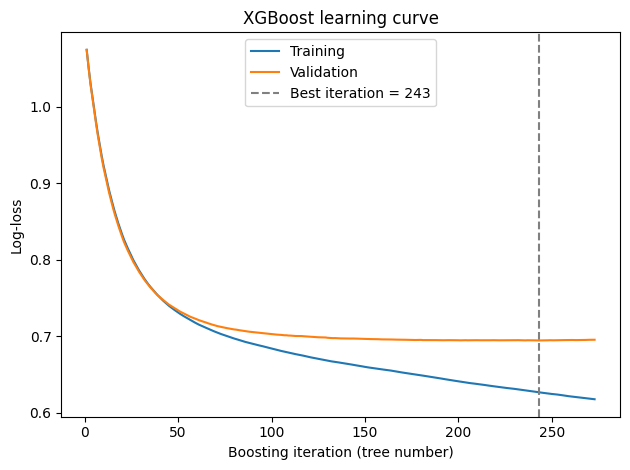

Best iteration: 242 | iterations actually run: 273


In [20]:
import matplotlib.pyplot as plt

ev = xgb_es.evals_result()
curve = pd.DataFrame({
    "iteration": range(1, len(ev["validation_0"]["mlogloss"]) + 1),
    "train_logloss": ev["validation_0"]["mlogloss"],
    "validation_logloss": ev["validation_1"]["mlogloss"],
})
curve.to_csv("/kaggle/working/xgb_learning_curve.csv", index=False)

plt.plot(curve["iteration"], curve["train_logloss"], label="Training")
plt.plot(curve["iteration"], curve["validation_logloss"], label="Validation")
plt.axvline(best_iter + 1, linestyle="--", color="gray", label=f"Best iteration = {best_iter + 1}")
plt.xlabel("Boosting iteration (tree number)"); plt.ylabel("Log-loss"); plt.legend()
plt.title("XGBoost learning curve")
plt.tight_layout()
plt.savefig("/kaggle/working/xgb_learning_curve.png", dpi=150)
plt.show()

print("Best iteration:", best_iter, "| iterations actually run:", len(curve))

In [21]:
# (a) The early-stopped model (trained on sessions 15-60), tested ONCE on sessions 76+
Xt = imp_c.transform(test_df[features]); yt = test_df["fatigue_class"]

t0 = time.perf_counter()
proba_a = xgb_es.predict_proba(Xt, iteration_range=(0, best_iter + 1))
pred_a = proba_a.argmax(axis=1)
pred_a_t = time.perf_counter() - t0
m_a = score(yt, pred_a, proba_a)

fit_a_t = float(tune.iloc[0]["fit_wall_time_sec"])
row_a = {"model": f"XGBoost early-stopped (best iteration {best_iter + 1} trees, depth {best_depth}, lr {best_lr}; trained on sessions 15-60)",
         "train_rows": len(core_df), "test_rows": len(test_df), "n_features": len(features),
         "train_wall_time_sec": round(fit_a_t, 4), "predict_wall_time_sec": round(pred_a_t, 4),
         "total_wall_time_sec": round(fit_a_t + pred_a_t, 4), **{k: round(v, 4) for k, v in m_a.items()}}

# (b) The BEST model: refit on sessions 15-75 using exactly best_iter + 1 trees, tested ONCE
best_pipe = make_xgb(n_estimators=best_iter + 1, learning_rate=best_lr, max_depth=best_depth)
t0 = time.perf_counter()
best_pipe.fit(train_df[features], train_df["fatigue_class"])
best_train_t = time.perf_counter() - t0
t0 = time.perf_counter()
pred_b = best_pipe.predict(test_df[features]); proba_b = best_pipe.predict_proba(test_df[features])
best_pred_t = time.perf_counter() - t0
m_b = score(yt, pred_b, proba_b)
row_b = {"model": f"XGBoost BEST model (refit on sessions 15-75 with {best_iter + 1} trees, depth {best_depth}, lr {best_lr})",
         "train_rows": len(train_df), "test_rows": len(test_df), "n_features": len(features),
         "train_wall_time_sec": round(best_train_t, 4), "predict_wall_time_sec": round(best_pred_t, 4),
         "total_wall_time_sec": round(best_train_t + best_pred_t, 4), **{k: round(v, 4) for k, v in m_b.items()}}

best_out = pd.DataFrame([row_a, row_b])
best_out.to_csv("/kaggle/working/xgb_best_model_metrics.csv", index=False)

compare = pd.concat([results.assign(model="XGBoost default (300 trees, depth 6, lr 0.1; sessions 15-75)"), best_out],
                    ignore_index=True)
compare.to_csv("/kaggle/working/xgb_default_vs_best_metrics.csv", index=False)
print(compare[["model", "accuracy", "f1_macro", "roc_auc_ovr_macro", "total_wall_time_sec"]].to_string(index=False))

                                                                                        model  accuracy  f1_macro  roc_auc_ovr_macro  total_wall_time_sec
                                 XGBoost default (300 trees, depth 6, lr 0.1; sessions 15-75)    0.6516    0.6513             0.8364               3.3505
XGBoost early-stopped (best iteration 243 trees, depth 3, lr 0.05; trained on sessions 15-60)    0.6656    0.6669             0.8467               0.9125
                XGBoost BEST model (refit on sessions 15-75 with 243 trees, depth 3, lr 0.05)    0.6696    0.6707             0.8491               0.8122


In [22]:
import joblib

# Default model (300 trees) and the BEST model (refit with the best number of trees)
joblib.dump(main_pipe, "/kaggle/working/xgboost_model.joblib")
joblib.dump(best_pipe, "/kaggle/working/xgboost_best_model.joblib")

# The early-stopped model in XGBoost's own format, plus the imputer it needs
xgb_es.save_model("/kaggle/working/xgboost_best_iteration_model.json")
joblib.dump(imp_c, "/kaggle/working/xgboost_imputer.joblib")

settings = {"q1": float(q1), "q2": float(q2), "features": features, "class_names": class_names,
            "first_prediction_session": 15, "history_windows": [7, 14],
            "best_iteration_index": best_iter, "best_trees_used": best_iter + 1,
            "best_max_depth": best_depth, "best_learning_rate": best_lr,
            "early_stopping_rounds": 30}
json.dump(settings, open("/kaggle/working/model_settings_xgb.json", "w"), indent=2)

pd.DataFrame([{"model": "XGBoost (early stopping)",
               "best_iteration_index": best_iter, "trees_used": best_iter + 1,
               "iterations_run": len(curve),
               "best_validation_logloss": round(float(xgb_es.best_score), 4),
               "max_depth": best_depth, "learning_rate": best_lr,
               "early_stopping_rounds": 30}]).to_csv("/kaggle/working/xgboost_best_iteration.csv", index=False)

# Reload checks
for name, path, orig in [("default", "/kaggle/working/xgboost_model.joblib", main_pipe),
                         ("best", "/kaggle/working/xgboost_best_model.joblib", best_pipe)]:
    loaded = joblib.load(path)
    print(f"Reloaded {name} model gives identical predictions:",
          bool((loaded.predict(X_test) == orig.predict(X_test)).all()))

es_loaded = XGBClassifier(); es_loaded.load_model("/kaggle/working/xgboost_best_iteration_model.json")
p_loaded = es_loaded.predict_proba(Xt, iteration_range=(0, best_iter + 1))
print("Reloaded early-stopped model gives identical probabilities:",
      bool(np.allclose(p_loaded, proba_a, atol=1e-6)))
print(sorted(os.listdir("/kaggle/working")))

Reloaded default model gives identical predictions: True
Reloaded best model gives identical predictions: True
Reloaded early-stopped model gives identical probabilities: True
['__notebook__.ipynb', 'model_settings_xgb.json', 'xgb_ablation.csv', 'xgb_ablation_prev_fatigue.csv', 'xgb_best_model_metrics.csv', 'xgb_counterfactual_example.csv', 'xgb_default_vs_best_metrics.csv', 'xgb_learning_curve.csv', 'xgb_learning_curve.png', 'xgb_permutation_importance.csv', 'xgb_shap_feature_importance.csv', 'xgb_shap_group_share.csv', 'xgb_shap_group_share.png', 'xgb_shap_summary_high.png', 'xgb_tuning_validation.csv', 'xgb_walk_forward.csv', 'xgboost_best_iteration.csv', 'xgboost_best_iteration_model.json', 'xgboost_best_model.joblib', 'xgboost_feature_importance.csv', 'xgboost_imputer.joblib', 'xgboost_metrics.csv', 'xgboost_model.joblib', 'xgboost_per_class.csv', 'xgboost_test_predictions.csv']


In [23]:
results_log = []
def record(name, passed, note=""):
    results_log.append({"test": name, "result": "PASS" if passed else "FAIL", "note": note})
    print(("PASS  " if passed else "FAIL  ") + name + (f"  ({note})" if note else ""))

In [24]:
bad = {"fatigue_index", "fatigue_class", "athlete_id", "session_id", "session_number"}
record("No target/ID columns in features", len(bad & set(features)) == 0)

overlap = set(zip(train_df.athlete_id, train_df.session_id)) & set(zip(test_df.athlete_id, test_df.session_id))
record("No row appears in both train and test", len(overlap) == 0)
record("All train sessions come before all test sessions",
       train_df.session_number.max() < test_df.session_number.min(),
       f"train max={train_df.session_number.max()}, test min={test_df.session_number.min()}")
record("Prediction rows start at session 15", model_df.session_number.min() == 15)

q1c, q2c = train_df["fatigue_index"].quantile([1/3, 2/3])
record("Class cut points match training data", np.isclose(q1c, q1) and np.isclose(q2c, q2))

stats = main_pipe.named_steps["fill_missing"].statistics_
record("Imputer medians equal TRAIN medians", np.allclose(stats, X_train.median().values, equal_nan=True))

# Recompute history features by hand for 300 random rows
sample = model_df.sample(300, random_state=0)
ok = True
for _, r in sample.iterrows():
    prev = df[(df.athlete_id == r.athlete_id) & (df.session_number < r.session_number)].sort_values("session_number")
    for w in [7, 14]:
        last = prev.tail(w)
        ok &= len(last) == w
        ok &= np.isclose(last.training_load.sum(),  r[f"load_sum_{w}"])
        ok &= np.isclose(last.training_load.mean(), r[f"load_mean_{w}"])
        ok &= np.isclose(r.training_load - last.training_load.mean(), r[f"load_minus_mean_{w}"])
        ok &= np.isclose(r.training_load / last.training_load.mean(), r[f"load_ratio_{w}"])
        for col in ["training_intensity", "heart_rate", "sleep_quality", "recovery_score", "stress_level"]:
            v = last[col]
            exp = v.mean() if v.notna().sum() >= 3 else np.nan
            got = r[f"{col}_mean_{w}"]
            ok &= (np.isnan(exp) and np.isnan(got)) or np.isclose(exp, got)
record("History features use only earlier sessions (300 random rows, every feature)", bool(ok))

PASS  No target/ID columns in features
PASS  No row appears in both train and test
PASS  All train sessions come before all test sessions  (train max=75, test min=76)
PASS  Prediction rows start at session 15
PASS  Class cut points match training data
PASS  Imputer medians equal TRAIN medians
PASS  History features use only earlier sessions (300 random rows, every feature)


In [25]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
dummy_f1 = f1_score(y_test, dummy.predict(X_test), average="macro")
record("Model clearly beats the dummy baseline", main_metrics["f1_macro"] > dummy_f1 + 0.2,
       f"model F1={main_metrics['f1_macro']:.3f}, dummy F1={dummy_f1:.3f}")

rng = np.random.default_rng(1)
shuffled = train_df.copy()
shuffled["fatigue_class"] = rng.permutation(shuffled["fatigue_class"].values)
_, _, _, m_shuf, _, _ = run_xgb(features, shuffled, test_df)
record("Shuffled labels drop F1 to about chance (no hidden leakage)",
       m_shuf["f1_macro"] < 0.40, f"F1 with shuffled labels = {m_shuf['f1_macro']:.3f}")

PASS  Model clearly beats the dummy baseline  (model F1=0.651, dummy F1=0.173)
PASS  Shuffled labels drop F1 to about chance (no hidden leakage)  (F1 with shuffled labels = 0.348)


In [26]:
from sklearn.model_selection import GroupKFold

fold_f1 = []
for tr_idx, te_idx in GroupKFold(n_splits=5).split(model_df, groups=model_df["athlete_id"]):
    tr, te = model_df.iloc[tr_idx], model_df.iloc[te_idx]
    _, _, _, m, _, _ = run_xgb(today_feats, tr, te)
    fold_f1.append(m["f1_macro"])

print("F1 per fold (athletes unseen in training):", np.round(fold_f1, 4))
print("Mean F1 on unseen athletes:", round(float(np.mean(fold_f1)), 4))
record("Works on unseen athletes (mean F1 > 0.5)", np.mean(fold_f1) > 0.5, f"mean F1={np.mean(fold_f1):.3f}")
pd.DataFrame({"fold": range(1, 6), "f1_macro": fold_f1}).to_csv("/kaggle/working/xgb_unseen_athletes.csv", index=False)

F1 per fold (athletes unseen in training): [0.6536 0.6393 0.6363 0.6528 0.6509]
Mean F1 on unseen athletes: 0.6466
PASS  Works on unseen athletes (mean F1 > 0.5)  (mean F1=0.647)


In [27]:
no_rec = [f for f in today_feats if f != "recovery_score"]
_, _, _, m_norec, _, _ = run_xgb(no_rec, train_df, test_df)
_, _, _, m_with,  _, _ = run_xgb(today_feats, train_df, test_df)
print(f"With recovery_score:    F1 = {m_with['f1_macro']:.4f}")
print(f"Without recovery_score: F1 = {m_norec['f1_macro']:.4f}")
print(f"Drop: {m_with['f1_macro'] - m_norec['f1_macro']:.4f}")

With recovery_score:    F1 = 0.6531
Without recovery_score: F1 = 0.6539
Drop: -0.0008


In [28]:
rng = np.random.default_rng(42)
sh = df[keep_cols].copy()
sh["rand"] = rng.random(len(sh))
sh = sh.sort_values(["athlete_id", "rand"]).drop(columns="rand").reset_index(drop=True)
sh["session_number"] = sh.groupby("athlete_id").cumcount() + 1
gs = sh.groupby("athlete_id")

for w in [7, 14]:
    sh[f"load_mean_{w}"] = gs["training_load"].transform(lambda s: s.shift(1).rolling(w, min_periods=w).mean())
for col in ["training_intensity", "heart_rate", "sleep_quality", "recovery_score", "stress_level"]:
    for w in [7, 14]:
        sh[f"{col}_mean_{w}"] = gs[col].transform(lambda s: s.shift(1).rolling(w, min_periods=3).mean())

sh = sh[sh.session_number >= 15].copy()
sh["fatigue_class"] = sh["fatigue_index"].apply(to_class)
sh_tr, sh_te = sh[sh.session_number <= 75], sh[sh.session_number >= 76]

hist_nodup = ["load_mean_7", "load_mean_14"] + [f"{c}_mean_{w}" for c in
              ["training_intensity", "heart_rate", "sleep_quality", "recovery_score", "stress_level"] for w in [7, 14]]
feats_c = today_feats + hist_nodup

_, _, _, m_real, _, _ = run_xgb(feats_c, train_df, test_df)
_, _, _, m_shuf2, _, _ = run_xgb(feats_c, sh_tr, sh_te)
print(f"Real order:     F1 = {m_real['f1_macro']:.4f}")
print(f"Shuffled order: F1 = {m_shuf2['f1_macro']:.4f}")

Real order:     F1 = 0.6547
Shuffled order: F1 = 0.6579


In [29]:
row = test_df.iloc[100]
a = df[df.athlete_id == row.athlete_id].sort_values("session_number")
prev = a[a.session_number < row.session_number]

new = {c: row[c] for c in today_feats}
for w in [7, 14]:
    last = prev.tail(w)
    new[f"load_sum_{w}"]  = last.training_load.sum()
    new[f"load_mean_{w}"] = last.training_load.mean()
    new[f"load_minus_mean_{w}"] = row.training_load - last.training_load.mean()
    new[f"load_ratio_{w}"] = row.training_load / last.training_load.mean()
    for col in ["training_intensity", "heart_rate", "sleep_quality", "recovery_score", "stress_level"]:
        v = last[col]
        new[f"{col}_mean_{w}"] = v.mean() if v.notna().sum() >= 3 else np.nan

app_X = pd.DataFrame([new])[features]
app_proba   = main_pipe.predict_proba(app_X)[0]
batch_proba = main_pipe.predict_proba(test_df[features].iloc[[100]])[0]
record("App-style prediction equals batch prediction",
       np.allclose(app_proba, batch_proba, atol=1e-8),
       f"app={np.round(app_proba,4)}, batch={np.round(batch_proba,4)}")

PASS  App-style prediction equals batch prediction  (app=[1.000e-04 2.300e-03 9.976e-01], batch=[1.000e-04 2.300e-03 9.976e-01])


In [30]:
expected = ["xgboost_metrics.csv", "xgboost_per_class.csv",
            "xgboost_feature_importance.csv", "xgboost_test_predictions.csv",
            "xgb_ablation.csv", "xgb_walk_forward.csv", "xgb_shap_feature_importance.csv",
            "xgb_shap_group_share.csv", "xgb_permutation_importance.csv",
            "xgb_tuning_validation.csv", "xgb_learning_curve.csv", "xgb_best_model_metrics.csv",
            "xgboost_model.joblib", "xgboost_best_model.joblib",
            "xgboost_best_iteration_model.json", "xgboost_imputer.joblib",
            "model_settings_xgb.json", "xgboost_best_iteration.csv"]
missing = [f for f in expected if not os.path.exists("/kaggle/working/" + f)]
record("All expected output files exist", len(missing) == 0, f"missing: {missing}" if missing else "")

summary = pd.DataFrame(results_log)
summary.to_csv("/kaggle/working/xgb_test_report.csv", index=False)
print("\n", summary.to_string(index=False))

PASS  All expected output files exist

                                                                        test result                                                                       note
                                           No target/ID columns in features   PASS                                                                           
                                      No row appears in both train and test   PASS                                                                           
                           All train sessions come before all test sessions   PASS                                                  train max=75, test min=76
                                        Prediction rows start at session 15   PASS                                                                           
                                       Class cut points match training data   PASS                                                                           
            